In [ ]:
# Simple dataset generator using the finalized 3-neuron (2 presyn -> 1 post) API

import os
os.environ["JAX_PLATFORMS"] = "cpu"
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import numpy as np
import jax
import jax.numpy as jnp
from jax import random

from ThreeNeuron_JAX import (
    ModelParams, NoiseParams,
    simulate_pair_jit,   # runs the soft LIF model and gives (C, F) for 3 neurons
    noisy_F,             # adds noise based on heteroscedastic model
)

# Settings
N_SAMPLES = 100000
W_MIN, W_MAX = 1.5, 9.5   # range for each synaptic weight

SIGMA_C = 28.0
SIGMA_F = 4e-4
GAMMA   = 1e-4

SAVE_X = "X3N_2weights.npy"
SAVE_Y = "Y3N_traces.npy"

# Random number generators
np_rng = np.random.default_rng(1234)  # for sampling weights
jax_key = random.PRNGKey(1234)        # for JAX noise draws

# Simulator configuration
cfg = ModelParams()
noise = NoiseParams(sigma_f=SIGMA_F, gamma=GAMMA, sigma_c=SIGMA_C, floor=1e-3)

# Each fluorescence trace has length = total time / calcium bin
T_ca = int(round(cfg.sim_time / cfg.ca_bin))

# Allocate arrays for storage
X = np.empty((N_SAMPLES, 2), dtype=np.float32)       # two weights: [w0_to_2, w1_to_2]
Y = np.empty((N_SAMPLES, 3, T_ca), dtype=np.float32) # 3 neurons

# Generate dataset
i = 0
while i < N_SAMPLES:
    # pick random synaptic weights for 0->2 and 1->2
    w0 = np_rng.uniform(W_MIN, W_MAX)
    w1 = np_rng.uniform(W_MIN, W_MAX)
    w_vec = jnp.array([w0, w1], dtype=jnp.float32)

    # deterministic forward pass (clean calcium and fluorescence)
    C_clean, F_clean = simulate_pair_jit(w_vec, cfg)  # F_clean: (3, T_ca)

    # draw noisy fluorescence using JAX random key
    jax_key, subkey = random.split(jax_key)
    F_noisy, _ = noisy_F(F_clean, C_clean, cfg, noise, subkey)

    # save to arrays
    X[i, :]   = np.asarray(w_vec, dtype=np.float32)
    Y[i, 0, :] = np.asarray(F_noisy[0], dtype=np.float32)  # neuron 0
    Y[i, 1, :] = np.asarray(F_noisy[1], dtype=np.float32)  # neuron 1
    Y[i, 2, :] = np.asarray(F_noisy[2], dtype=np.float32)  # neuron 2 (postsynaptic)

    i += 1
    if i % 1000 == 0:
        print(f"{i} samples generated")

# Save results
np.save(SAVE_X, X)                  # (N_SAMPLES, 2)
np.save(SAVE_Y, Y)                  # (N_SAMPLES, 3, T_ca)
print(f"Done! Saved {SAVE_X} and {SAVE_Y}")


WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


1000 samples generated
2000 samples generated
3000 samples generated
4000 samples generated
5000 samples generated
6000 samples generated
7000 samples generated
8000 samples generated
9000 samples generated
10000 samples generated
11000 samples generated
12000 samples generated
13000 samples generated
14000 samples generated
15000 samples generated
16000 samples generated
17000 samples generated
18000 samples generated
19000 samples generated
20000 samples generated
21000 samples generated
22000 samples generated
23000 samples generated
24000 samples generated
25000 samples generated
26000 samples generated
27000 samples generated
28000 samples generated
29000 samples generated
30000 samples generated
31000 samples generated
32000 samples generated
33000 samples generated
34000 samples generated
35000 samples generated
36000 samples generated
37000 samples generated
38000 samples generated
39000 samples generated
40000 samples generated
41000 samples generated
42000 samples generated
4

In [ ]:
# Generate multiple noisy samples for each fixed weight pair using the 3-neuron API

import os
os.environ["JAX_PLATFORMS"] = "cpu"
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import numpy as np
import jax
from jax import random
import jax.numpy as jnp

from ThreeNeuron_JAX import (
    ModelParams, NoiseParams,
    simulate_pair_jit,
    noisy_F,
)

# number of noisy samples per weight pair
N_SAMPLES = 10000

# fixed weight pairs: [w0->2, w1->2]
FIXED_WEIGHT_PAIRS = [
    (4.0, 5.5),   
    (4.5, 7.0),   
    (6.0, 6.0),   
    (8.0, 7.5),  
]


# random key for noise
jax_key = random.PRNGKey(1234)

# simulator config and noise model
cfg = ModelParams()
noise = NoiseParams(
    sigma_f=4e-4,
    gamma=1e-4,
    sigma_c=28.0,
    floor=1e-3,
)

T_ca = int(round(cfg.sim_time / cfg.ca_bin))

for (w0, w1) in FIXED_WEIGHT_PAIRS:
    label = f"w0_{w0}_w1_{w1}"
    print(f"Generating {N_SAMPLES} noisy samples for (w0, w1) = ({w0:.1f}, {w1:.1f}) mV...")

    # store weights and traces
    X = np.zeros((N_SAMPLES, 2), dtype=np.float32)
    Y = np.empty((N_SAMPLES, 3, T_ca), dtype=np.float32)

    for i in range(N_SAMPLES):
        w_vec = jnp.array([w0, w1], dtype=jnp.float32)

        # deterministic forward
        C_clean, F_clean = simulate_pair_jit(w_vec, cfg)

        # add noise
        jax_key, subkey = random.split(jax_key)
        F_noisy, _ = noisy_F(F_clean, C_clean, cfg, noise, subkey)

        X[i, :]   = np.array([w0, w1], dtype=np.float32)
        Y[i, 0, :] = np.asarray(F_noisy[0], dtype=np.float32)  # neuron 0
        Y[i, 1, :] = np.asarray(F_noisy[1], dtype=np.float32)  # neuron 1
        Y[i, 2, :] = np.asarray(F_noisy[2], dtype=np.float32)  # neuron 2 (post)

        if (i + 1) % 1000 == 0:
            print(f"  {i+1} / {N_SAMPLES} done")

    # save with clear file names
    np.save(f"X_{label}.npy", X)
    np.save(f"Y_{label}.npy", Y)
    print(f"Saved X_{label}.npy {X.shape}, Y_{label}.npy {Y.shape}")


Generating 20000 noisy samples for (w0, w1) = (4.0, 5.5) mV...
  1000 / 20000 done
  2000 / 20000 done
  3000 / 20000 done
  4000 / 20000 done
  5000 / 20000 done
  6000 / 20000 done
  7000 / 20000 done
  8000 / 20000 done
  9000 / 20000 done
  10000 / 20000 done
  11000 / 20000 done
  12000 / 20000 done
  13000 / 20000 done
  14000 / 20000 done
  15000 / 20000 done
  16000 / 20000 done
  17000 / 20000 done
  18000 / 20000 done
  19000 / 20000 done
  20000 / 20000 done
Saved X_w0_4.0_w1_5.5.npy (20000, 2), Y_w0_4.0_w1_5.5.npy (20000, 3, 300)
Generating 20000 noisy samples for (w0, w1) = (4.5, 7.0) mV...
  1000 / 20000 done
  2000 / 20000 done
  3000 / 20000 done
  4000 / 20000 done
  5000 / 20000 done
  6000 / 20000 done
  7000 / 20000 done
  8000 / 20000 done
  9000 / 20000 done
  10000 / 20000 done
  11000 / 20000 done
  12000 / 20000 done
  13000 / 20000 done
  14000 / 20000 done
  15000 / 20000 done
  16000 / 20000 done
  17000 / 20000 done
  18000 / 20000 done
  19000 / 20000 done

C:\Users\Suman\AppData\Local\Temp\ipykernel_35520\1628417876.py:75: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.09, 1, 0.97])


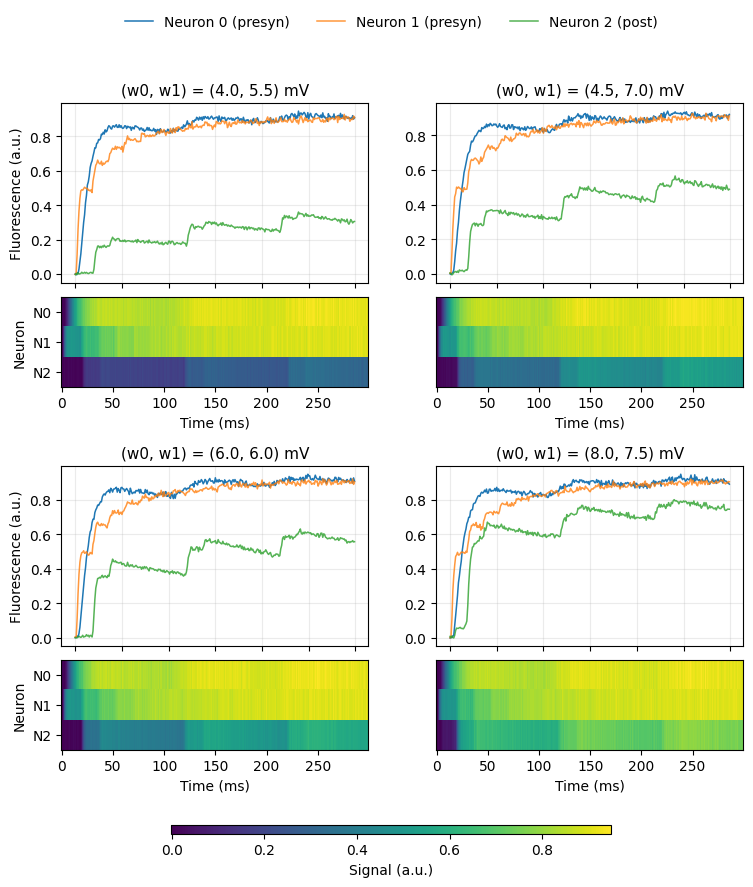

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import os

# which fixed weight pairs to visualise (must match those used above)
weight_pairs_to_plot = [
    (4.0, 5.5),   
    (4.5, 7.0),   
    (6.0, 6.0),  
    (8.0, 7.5),   
]

fig = plt.figure(figsize=(8.8, 8.4))
gs = GridSpec(2, 2, figure=fig, hspace=0.28, wspace=0.22)

for i, (w0, w1) in enumerate(weight_pairs_to_plot):
    label = f"w0_{w0}_w1_{w1}"

    # load one of the fixed-weight datasets
    X = np.load(f"X_{label}.npy")
    Y = np.load(f"Y_{label}.npy")  # (N_SAMPLES, 3, T_ca)

    r, c = divmod(i, 2)

    # pick a representative sample (first one is fine, or random)
    idx = 0
    trace0 = Y[idx, 0, :]
    trace1 = Y[idx, 1, :]
    trace2 = Y[idx, 2, :]
    t_ms = np.arange(trace0.size)

    # sub-grid for traces + heatmap
    inner_gs = gs[r, c].subgridspec(2, 1, height_ratios=[2, 1], hspace=0.1)

    # --- Traces ---
    ax1 = fig.add_subplot(inner_gs[0])
    ln0 = ax1.plot(t_ms, trace0, lw=1.1, label='Neuron 0 (presyn)')[0]
    ln1 = ax1.plot(t_ms, trace1, lw=1.1, label='Neuron 1 (presyn)', alpha=0.8)[0]
    ln2 = ax1.plot(t_ms, trace2, lw=1.1, label='Neuron 2 (post)', alpha=0.8)[0]

    ax1.set_title(f"(w0, w1) = ({w0:.1f}, {w1:.1f}) mV", fontsize=11)
    ax1.set_xticklabels([])
    ax1.grid(alpha=0.25)
    if c == 0:
        ax1.set_ylabel('Fluorescence (a.u.)')

    # --- Heatmap ---
    ax2 = fig.add_subplot(inner_gs[1])
    stack_traces = np.vstack([trace0, trace1, trace2])
    im = ax2.imshow(stack_traces, aspect='auto', cmap='viridis', interpolation='nearest')
    if c == 0:
        ax2.set_yticks([0, 1, 2])
        ax2.set_yticklabels(['N0', 'N1', 'N2'])
        ax2.set_ylabel('Neuron')
    else:
        ax2.set_yticks([])
    ax2.set_xlabel('Time (ms)')

# Shared legend and colorbar
fig.legend(
    [ln0, ln1, ln2],
    ['Neuron 0 (presyn)', 'Neuron 1 (presyn)', 'Neuron 2 (post)'],
    loc='upper center',
    ncol=3,
    frameon=False,
    fontsize=10,
    bbox_to_anchor=(0.5, 1.0)
)

cbar_ax = fig.add_axes([0.25, 0.01, 0.5, 0.01])
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Signal (a.u.)', labelpad=4)

plt.tight_layout(rect=[0, 0.09, 1, 0.97])

os.makedirs("plots", exist_ok=True)
plt.savefig("plots/three_neuron_fixed_weights.png", dpi=300, bbox_inches='tight')
plt.show()


In [4]:
import numpy as np

# Load your data
X = np.load("X3N_2weights.npy")  # (1000, 2)
Y = np.load("Y3N_traces.npy")    # (1000, 3, 300)

# Extract postsynaptic traces
Y_post = Y[:, 2, :]  # (1000, 300)

# Check if w0 and w1 correlate with postsynaptic signal
w0_corr = np.corrcoef(X[:, 0], Y_post.mean(axis=1))[0, 1]
w1_corr = np.corrcoef(X[:, 1], Y_post.mean(axis=1))[0, 1]

print(f"Correlation w0 → postsynaptic: {w0_corr:.3f}")
print(f"Correlation w1 → postsynaptic: {w1_corr:.3f}")


Correlation w0 → postsynaptic: 0.811
Correlation w1 → postsynaptic: 0.541
